In [63]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE

In [64]:
# Dataset
df = pd.read_csv("synthetic_credit_risk.csv")
df

,age,monthly_income,debt_ratio,credit_utilization,transaction_count_30d,avg_transaction_amount,employment_type,education_level,region,device_type,last_payment_delay_days,internal_score_v2,target
0,43.6,67139.59,0.341,0.508,44,56.04,contract,master,rural,desktop,0.30,546.3,0
1,42.3,69322.76,0.318,0.427,43,71.57,contract,master,urban,desktop,2.16,583.2,0
2,29.4,31240.70,0.380,0.519,43,88.01,full_time,high_school,suburban,tablet,1.14,544.0,0
3,52.5,23838.70,0.372,0.481,50,69.37,full_time,bachelor,urban,tablet,4.56,569.4,0
4,44.0,36584.21,0.129,0.213,44,93.56,contract,bachelor,urban,mobile,1.78,669.9,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,41.3,76901.04,0.176,0.471,52,59.06,contract,high_school,urban,desktop,3.16,628.2,1
14996,37.3,50768.66,0.488,0.592,47,91.91,full_time,bachelor,suburban,desktop,2.22,480.7,0
14997,47.6,47376.66,0.241,0.411,37,124.75,full_time,high_school,urban,mobile,9.19,575.2,0
14998,23.0,23273.23,0.744,1.000,64,126.09,unemployed,bachelor,suburban,mobile,13.44,376.2,1


In [65]:
# First 5 rows
df.head()

,age,monthly_income,debt_ratio,credit_utilization,transaction_count_30d,avg_transaction_amount,employment_type,education_level,region,device_type,last_payment_delay_days,internal_score_v2,target
0,43.6,67139.59,0.341,0.508,44,56.04,contract,master,rural,desktop,0.30,546.3,0
1,42.3,69322.76,0.318,0.427,43,71.57,contract,master,urban,desktop,2.16,583.2,0
2,29.4,31240.70,0.380,0.519,43,88.01,full_time,high_school,suburban,tablet,1.14,544.0,0
3,52.5,23838.70,0.372,0.481,50,69.37,full_time,bachelor,urban,tablet,4.56,569.4,0
4,44.0,36584.21,0.129,0.213,44,93.56,contract,bachelor,urban,mobile,1.78,669.9,0


In [66]:
# Last 5 rows
df.tail()

,age,monthly_income,debt_ratio,credit_utilization,transaction_count_30d,avg_transaction_amount,employment_type,education_level,region,device_type,last_payment_delay_days,internal_score_v2,target
14995,41.3,76901.04,0.176,0.471,52,59.06,contract,high_school,urban,desktop,3.16,628.2,1
14996,37.3,50768.66,0.488,0.592,47,91.91,full_time,bachelor,suburban,desktop,2.22,480.7,0
14997,47.6,47376.66,0.241,0.411,37,124.75,full_time,high_school,urban,mobile,9.19,575.2,0
14998,23.0,23273.23,0.744,1.000,64,126.09,unemployed,bachelor,suburban,mobile,13.44,376.2,1
14999,22.0,40842.80,0.193,0.136,47,98.26,full_time,bachelor,urban,mobile,1.28,685.9,0


In [67]:
print("Shape of Dataset")
df.shape

Shape of Dataset


(15000, 13)

In [68]:
# Description of dataset
print("Descriptive Statistics of Numerical Column")
df.describe()

Descriptive Statistics of Numerical Column


,age,monthly_income,debt_ratio,credit_utilization,transaction_count_30d,avg_transaction_amount,last_payment_delay_days,internal_score_v2,target
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,45.557853,43234.147455,0.334668,0.400615,43.333800,92.102736,2.586447,587.514093,0.077200
std,11.014118,21169.380032,0.154811,0.196154,8.584231,35.616869,3.416169,57.425613,0.266917
min,18.000000,4024.160000,0.000000,0.000000,18.000000,10.000000,0.000000,276.500000,0.000000
25%,38.200000,28488.085000,0.229000,0.265000,38.000000,67.320000,0.650000,557.700000,0.000000
50%,45.600000,39141.395000,0.328000,0.392000,42.000000,91.655000,1.620000,592.600000,0.000000
75%,52.900000,53188.735000,0.431000,0.521000,47.000000,115.682500,3.260000,624.825000,0.000000
max,75.000000,205203.980000,1.000000,1.000000,95.000000,239.500000,50.430000,750.200000,1.000000


In [69]:
# Datatypes
print("Datatypes of Each Column")
print(df.dtypes)

Datatypes of Each Column
age                        float64
monthly_income             float64
debt_ratio                 float64
credit_utilization         float64
transaction_count_30d        int64
avg_transaction_amount     float64
employment_type             object
education_level             object
region                      object
device_type                 object
last_payment_delay_days    float64
internal_score_v2          float64
target                       int64
dtype: object


In [70]:
# Summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      15000 non-null  float64
 1   monthly_income           15000 non-null  float64
 2   debt_ratio               15000 non-null  float64
 3   credit_utilization       15000 non-null  float64
 4   transaction_count_30d    15000 non-null  int64  
 5   avg_transaction_amount   15000 non-null  float64
 6   employment_type          15000 non-null  object 
 7   education_level          15000 non-null  object 
 8   region                   15000 non-null  object 
 9   device_type              15000 non-null  object 
 10  last_payment_delay_days  15000 non-null  float64
 11  internal_score_v2        15000 non-null  float64
 12  target                   15000 non-null  int64  
dtypes: float64(7), int64(2), object(4)
memory usage: 1.5+ MB


In [71]:
# Null values count
missing_values = df.isnull().sum()
print("Missing Values for Each Column: ")
print(missing_values)

Missing Values for Each Column: 
age                        0
monthly_income             0
debt_ratio                 0
credit_utilization         0
transaction_count_30d      0
avg_transaction_amount     0
employment_type            0
education_level            0
region                     0
device_type                0
last_payment_delay_days    0
internal_score_v2          0
target                     0
dtype: int64


In [72]:
#Duplicate Row Count
duplicates = df.duplicated().sum()
print("Duplicated Row Count :")
print(duplicates)

Duplicated Row Count :
0


In [73]:
# Class Distributioun Count
y = df['target']
print("Original class distribution:", Counter(y))

Original class distribution: Counter({0: 13842, 1: 1158})


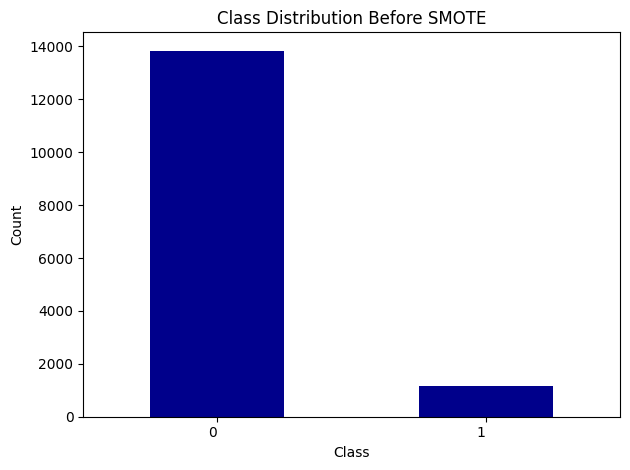

In [74]:
# Visual presentation of count of classes before applying SMOTE
df['target'].value_counts().plot(kind='bar' , color = 'darkblue')

plt.title("Class Distribution Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation = 360 , ha = 'right')
plt.tight_layout()
plt.show()

In [75]:
# Encoding categorial columns
df_encoded = pd.get_dummies(df, columns=[
    'employment_type',
    'education_level',
    'region',
    'device_type'])

In [76]:
# Target and Feature
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

In [77]:
# Train - Test - Split the model
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 , stratify = y
)

In [78]:
# Before Applying SMOTE
print("Before OverSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before OverSampling, counts of label '0': {} \n".format(sum(y_train == 0)))

Before OverSampling, counts of label '1': 926
Before OverSampling, counts of label '0': 11074 



In [79]:
# Baseline Model(Before SMOTE)
base_model = RandomForestClassifier(random_state=42)
base_model.fit(X_train, y_train)

base_pred = base_model.predict(X_test)

print("Baseline Model Results")
print(confusion_matrix(y_test, base_pred))
print(classification_report(y_test, base_pred))

Baseline Model Results
[[2762    6]
 [  85  147]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      2768
           1       0.96      0.63      0.76       232

    accuracy                           0.97      3000
   macro avg       0.97      0.82      0.87      3000
weighted avg       0.97      0.97      0.97      3000



In [80]:
# Applying SMOTE
model = SMOTE(random_state=42)
X_train_smote, y_train_smote = model.fit_resample(X_train, y_train)

In [81]:
# After applying SMOTE
print("After OverSampling, counts of label '1': {}".format(sum(y_train_smote == 1)))
print("After OverSampling, counts of label '0': {}".format(sum(y_train_smote == 0)))

After OverSampling, counts of label '1': 11074
After OverSampling, counts of label '0': 11074


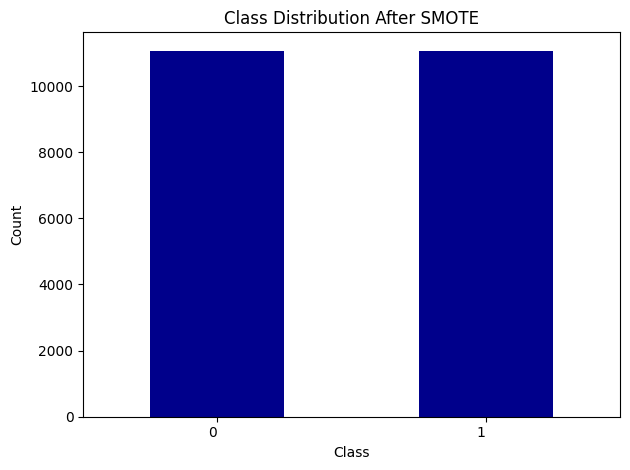

In [82]:
# Visual presentation of count of classes after applying SMOTE
pd.Series(y_train_smote).value_counts().plot(kind='bar' , color = 'darkblue')

plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation = 360 , ha = 'right')
plt.tight_layout()
plt.show()

In [83]:
# Train Model
model_smote = RandomForestClassifier(random_state=42)
model_smote.fit(X_train_smote, y_train_smote)

RandomForestClassifier(random_state=42)

In [84]:
# Predictions
y_pred_smote= model_smote.predict(X_test)

# Calculating Model Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_smote))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))

print("\nClassification Report (F1 Score):")
print(classification_report(y_test, y_pred_smote))

Accuracy: 0.9666666666666667

Confusion Matrix:
[[2750   18]
 [  82  150]]

Classification Report (F1 Score):
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      2768
           1       0.89      0.65      0.75       232

    accuracy                           0.97      3000
   macro avg       0.93      0.82      0.87      3000
weighted avg       0.96      0.97      0.96      3000

